<a href="https://colab.research.google.com/github/ZahraEmamii/Emotion-recognition/blob/main/Emotion-recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing libraries

In [9]:
!pip install tensorflow
!pip install livelossplot

In [2]:
!wget -c "https://github.com/katoch99/Emotion-Recognition/archive/refs/heads/master.zip"
!unzip "/content/master.zip" -d "/content/"

--2025-08-21 10:55:22--  https://github.com/katoch99/Emotion-Recognition/archive/refs/heads/master.zip
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/katoch99/Emotion-Recognition/zip/refs/heads/master [following]
--2025-08-21 10:55:22--  https://codeload.github.com/katoch99/Emotion-Recognition/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.121.9
Connecting to codeload.github.com (codeload.github.com)|140.82.121.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [           <=>      ]  58.49M  19.9MB/s    in 2.9s    

2025-08-21 10:55:25 (19.9 MB/s) - ‘master.zip’ saved [61333515]

Archive:  /content/master.zip
670bf684ad1497782558c0c1cb121bb5f3e42ec4
replace /content/Emotion-Recognition-ma

In [3]:
!unzip "/content/Emotion-Recognition-master/train/angry.zip" -d "/content/Emotion-Recognition-master/train/"
!unzip "/content/Emotion-Recognition-master/train/disgust.zip" -d "/content/Emotion-Recognition-master/train/"
!unzip "/content/Emotion-Recognition-master/train/fear.zip" -d "/content/Emotion-Recognition-master/train/"
!unzip "/content/Emotion-Recognition-master/train/happy.zip" -d "/content/Emotion-Recognition-master/train/"
!unzip "/content/Emotion-Recognition-master/train/neutral.zip" -d "/content/Emotion-Recognition-master/train/"
!unzip "/content/Emotion-Recognition-master/train/sad.zip" -d "/content/Emotion-Recognition-master/train/"
!unzip "/content/Emotion-Recognition-master/train/surprise.zip" -d "/content/Emotion-Recognition-master/train/"


unzip:  cannot find or open /content/Emotion-Recognition-master/train/angry.zip, /content/Emotion-Recognition-master/train/angry.zip.zip or /content/Emotion-Recognition-master/train/angry.zip.ZIP.
unzip:  cannot find or open /content/Emotion-Recognition-master/train/disgust.zip, /content/Emotion-Recognition-master/train/disgust.zip.zip or /content/Emotion-Recognition-master/train/disgust.zip.ZIP.
unzip:  cannot find or open /content/Emotion-Recognition-master/train/fear.zip, /content/Emotion-Recognition-master/train/fear.zip.zip or /content/Emotion-Recognition-master/train/fear.zip.ZIP.
unzip:  cannot find or open /content/Emotion-Recognition-master/train/happy.zip, /content/Emotion-Recognition-master/train/happy.zip.zip or /content/Emotion-Recognition-master/train/happy.zip.ZIP.
unzip:  cannot find or open /content/Emotion-Recognition-master/train/neutral.zip, /content/Emotion-Recognition-master/train/neutral.zip.zip or /content/Emotion-Recognition-master/train/neutral.zip.ZIP.
unzip:

In [4]:
!rm "/content/Emotion-Recognition-master/train/angry.zip"
!rm "/content/Emotion-Recognition-master/train/disgust.zip"
!rm "/content/Emotion-Recognition-master/train/fear.zip"
!rm "/content/Emotion-Recognition-master/train/happy.zip"
!rm "/content/Emotion-Recognition-master/train/neutral.zip"
!rm "/content/Emotion-Recognition-master/train/sad.zip"
!rm "/content/Emotion-Recognition-master/train/surprise.zip"

rm: cannot remove '/content/Emotion-Recognition-master/train/angry.zip': No such file or directory
rm: cannot remove '/content/Emotion-Recognition-master/train/disgust.zip': No such file or directory
rm: cannot remove '/content/Emotion-Recognition-master/train/fear.zip': No such file or directory
rm: cannot remove '/content/Emotion-Recognition-master/train/happy.zip': No such file or directory
rm: cannot remove '/content/Emotion-Recognition-master/train/neutral.zip': No such file or directory
rm: cannot remove '/content/Emotion-Recognition-master/train/sad.zip': No such file or directory
rm: cannot remove '/content/Emotion-Recognition-master/train/surprise.zip': No such file or directory


In [5]:
!unzip "/content/Emotion-Recognition-master/test/test.zip" -d "/content/Emotion-Recognition-master/"
!rm "/content/Emotion-Recognition-master/test/test.zip"


unzip:  cannot find or open /content/Emotion-Recognition-master/test/test.zip, /content/Emotion-Recognition-master/test/test.zip.zip or /content/Emotion-Recognition-master/test/test.zip.ZIP.
rm: cannot remove '/content/Emotion-Recognition-master/test/test.zip': No such file or directory


In [18]:
# Import libraries
import os,cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pylab import rcParams
rcParams['figure.figsize'] = 6, 6
import random
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split,ConcatDataset
import numpy as np
import seaborn as sns
%matplotlib inline
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Input, Dropout,Flatten, Conv2D
from tensorflow.keras.layers import BatchNormalization, Activation, MaxPooling2D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model
from livelossplot import PlotLossesKerasTF
import tensorflow as tf

In [19]:
print("\nTraining dataset\n")
for expression in os.listdir("/content/Emotion-Recognition-master/train/"):
    print(str(len(os.listdir("/content/Emotion-Recognition-master/train/" + expression))) + " " + expression + " images")
print("\nTest dataset\n")
for expression in os.listdir("/content/Emotion-Recognition-master/test/"):
    print(str(len(os.listdir("/content/Emotion-Recognition-master/test/" + expression))) + " " + expression + " images")


Training dataset

4830 sad images
3995 angry images
4097 fear images
436 disgust images
7214 happy images
3171 surprise images
4965 neutral images

Test dataset

1247 sad images
958 angry images
1024 fear images
111 disgust images
1774 happy images
831 surprise images
1233 neutral images


In [30]:
img_size = 48
batch_size = 64

datagen_train = ImageDataGenerator(horizontal_flip=True)

train_generator = datagen_train.flow_from_directory("/content/Emotion-Recognition-master/train/",
                                                    target_size=(img_size,img_size),
                                                    color_mode="grayscale",
                                                    batch_size=batch_size,
                                                    class_mode='categorical',
                                                    shuffle=True)

datagen_validation = ImageDataGenerator(horizontal_flip=True)
validation_generator = datagen_validation.flow_from_directory("/content/Emotion-Recognition-master/test/",
                                                    target_size=(img_size,img_size),
                                                    color_mode="grayscale",
                                                    batch_size=batch_size,
                                                    class_mode='categorical',
                                                    shuffle=True)
classes = ('angry', 'disgust', 'fear', 'happy',
           'neutral', 'sad', 'surprise')

Found 28708 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


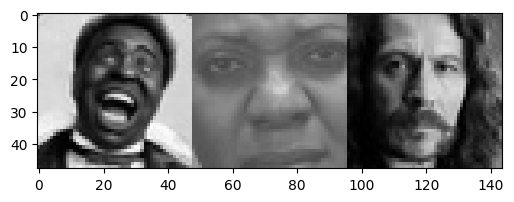

        happy                  angry                neutral


In [31]:
# functions to show an image
def imshow(img):
    #img = img / 2 + 0.5     # unnormalize
    #npimg = img.numpy()
    width=img.shape[1]
    newimg=img[0]
    for i,image in enumerate(img):
      if i!=0:
        newimg=np.concatenate((newimg,image),axis=1)
    newimg=np.transpose(newimg, (2,0,1))
    plt.imshow(newimg[0],cmap='gray')
    plt.show()


# get some random training images
dataiter = iter(train_generator)
images1, labels1 = next(dataiter)
label=np.where(labels1==1)[1]
# show images
imshow(images1[:3])
# print labels
print('          '.join('%13s' % classes[label[j]] for j in range(3)))

In [32]:
model = Sequential()

model.add(Conv2D(64,(3,3), padding='same', input_shape=(img_size, img_size,1)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128,(5,5), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(256,(3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(512,(3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(256))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))

model.add(Dense(512))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))

model.add(Dense(7, activation='softmax'))

opt = Adam(learning_rate=0.0005)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,02

 Total params: 3,002,887 (11.46 MB)

 Trainable params: 2,999,431 (11.44 MB)

 Non-trainable params: 3,456 (13.50 KB)

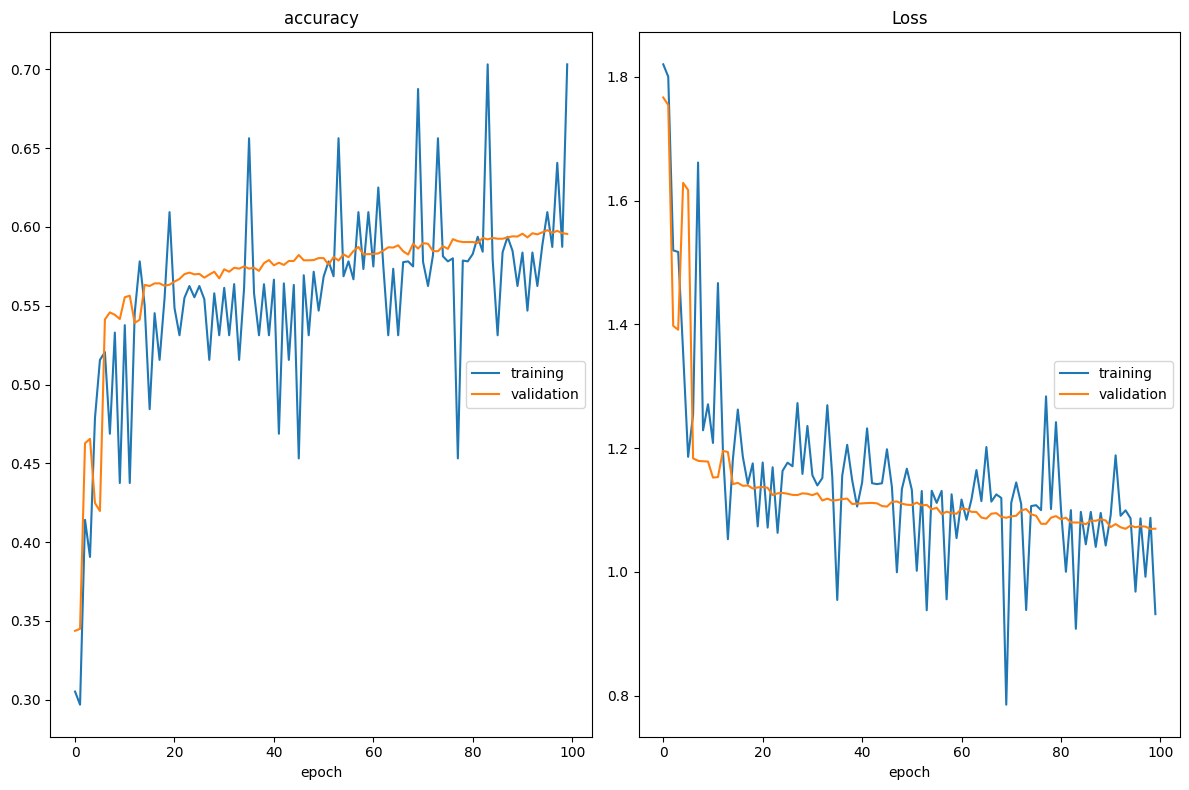

accuracy
	training         	 (min:    0.297, max:    0.703, cur:    0.703)
	validation       	 (min:    0.344, max:    0.598, cur:    0.596)
Loss
	training         	 (min:    0.785, max:    1.820, cur:    0.932)
	validation       	 (min:    1.069, max:    1.767, cur:    1.070)

Epoch 100: saving model to model_weights.weights.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7031 - loss: 0.9317 - val_accuracy: 0.5956 - val_loss: 1.0699 - learning_rate: 1.0000e-05
CPU times: user 16min 19s, sys: 1min 43s, total: 18min 2s
Wall time: 21min


In [33]:
%%time

epochs = 100
steps_per_epoch = train_generator.n//train_generator.batch_size
validation_steps = validation_generator.n//validation_generator.batch_size

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1,
                              patience=2, min_lr=0.00001, mode='auto')
checkpoint = ModelCheckpoint("model_weights.weights.h5", monitor='val_accuracy',
                             save_weights_only=True, mode='max', verbose=1)
callbacks = [PlotLossesKerasTF(), checkpoint, reduce_lr]

history = model.fit(
    x=train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    validation_data = validation_generator,
    validation_steps = validation_steps,
    callbacks=callbacks
)

In [34]:
model_json = model.to_json()
with open("/content/Emotion-Recognition-master/model.json", "w") as json_file:
    json_file.write(model_json)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


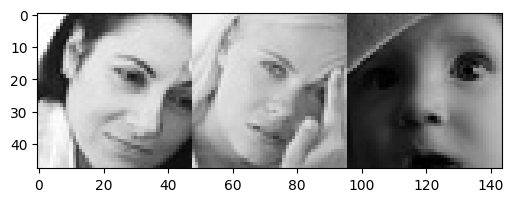

Actual labels:
         fear                neutral               surprise
Predicted labels:
          sad                    sad               surprise


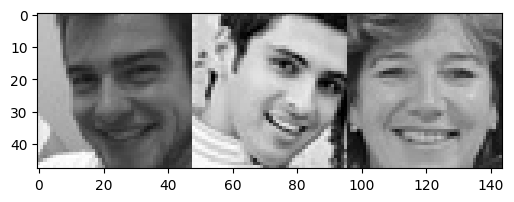

Actual labels:
        happy                  happy                  happy
Predicted labels:
        happy                  happy                  happy


In [43]:
# get some random test images
dataiter = iter(validation_generator)
images1, labels1 = next(dataiter)
label=np.where(labels1==1)[1]
predictions = np.argmax(model.predict(images1[:6]),axis=1)
predicted_classes=[classes[predictions[j]] for j in range(6)]
# show images
imshow(images1[:3])
# print actual and predicted labels
print('Actual labels:')
print('          '.join('%13s' % classes[label[j]] for j in range(3)))
print('Predicted labels:')
print('          '.join('%13s' % classes[predictions[j]] for j in range(3)))
# show images
imshow(images1[3:6])
# print actual and predicted labels
print('Actual labels:')
print('          '.join('%13s' % classes[label[j+3]] for j in range(3)))
print('Predicted labels:')
print('          '.join('%13s' % classes[predictions[j+3]] for j in range(3)))

###### ============================================
### To run this section:
###   - Put 6 images of your own choice in the folder: "/content/MyPic/MyPic"
######    - Supported formats: .jpg, .png
######  ============================================
######  Example code (commented out):
######  image_paths = [
######      "/content/MyPic/MyPic/1.jpg",
######      "/content/MyPic/MyPic/2.jpg",
######      "/content/MyPic/MyPic/3.jpg",
######      "/content/MyPic/MyPic/4.jpg",
######      "/content/MyPic/MyPic/5.jpg",
######      "/content/MyPic/MyPic/6.jpg"
######  ]


In [13]:
!mkdir "/content/MyPic"
!mkdir "/content/MyPic/MyPic"

In [13]:
mypics = datagen_train.flow_from_directory("/content/MyPic/",
                                                    target_size=(img_size,img_size),
                                                    color_mode="grayscale",
                                                    batch_size=batch_size,
                                                    class_mode='categorical',
                                                    shuffle=False)

dataiter = iter(mypics)
images1, labels1 = next(dataiter)
predictions = np.argmax(model.predict(images1[:6]),axis=1)
predicted_classes=[classes[predictions[j]] for j in range(6)]
# show images
imshow(images1[:3])
# print actual and predicted labels
print('Predicted labels:')
print(' '.join('%13s' % classes[predictions[j]] for j in range(3)))
# show images
imshow(images1[3:6])
# print actual and predicted labels
print('Predicted labels:')
print(' '.join('%13s' % classes[predictions[j+3]] for j in range(3)))

In [46]:
print("Evaluate on test data")
test_data_num=7178
alltest_generator = datagen_validation.flow_from_directory("/content/Emotion-Recognition-master/test/",
                                                    target_size=(img_size,img_size),
                                                    color_mode="grayscale",
                                                    batch_size=test_data_num,
                                                    class_mode='categorical',
                                                    shuffle=True)
dataiter = iter(alltest_generator)
images2, labels2 = next(dataiter)
results = model.evaluate(images2, labels2, batch_size=test_data_num)
print("Accuracy for all 7178 test images:", np.round(results[1]*100,2),"%")

### Plot normalized confusion matrix to show prediction accuracy and misclassifications per label

In [47]:
test_predictions = np.argmax(model.predict(images2),axis=1)
test_labels=np.argmax(labels2,axis=1)
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

for label, prediction in zip(test_labels, test_predictions):
    if label == prediction:
        correct_pred[classes[int(label)]] += 1
    total_pred[classes[int(label)]] += 1

# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print("Accuracy for class {:5s} is: {:.1f} %".format(classname,
                                                   accuracy))

225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
Accuracy for class angry is: 42.5 %
Accuracy for class disgust is: 38.7 %
Accuracy for class fear  is: 18.9 %
Accuracy for class happy is: 84.2 %
Accuracy for class neutral is: 60.1 %
Accuracy for class sad   is: 60.7 %
Accuracy for class surprise is: 78.6 %


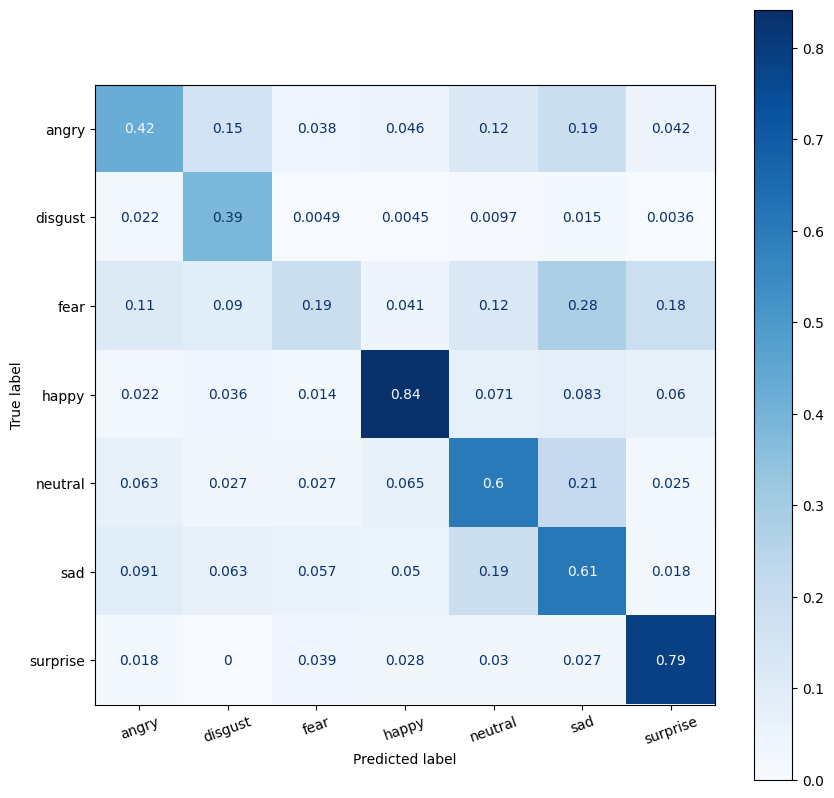

In [48]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
def plot_confusion_matrix(labels, pred_labels, classes):

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(1, 1, 1)
    cm = confusion_matrix(labels, pred_labels)
    cm=cm/cm.astype(float).sum(axis=1)
    cm = ConfusionMatrixDisplay(cm, display_labels=classes)
    cm.plot( cmap='Blues', ax=ax)
    plt.xticks(rotation=20)
plot_confusion_matrix(test_labels, test_predictions, classes)